# 06. YOLO로 가위바위보 판정기 만들기 (실습) — 정답

이 실습은 `src/yolo/rps/`에 이미 구현된 YOLO 기반 가위바위보 인식기를 **직접
재구현**해봅니다. 05강(OpenCV)과 정반대 접근입니다 — 규칙을 짜는 대신 미리 학습된
가중치를 불러와 추론만 하고, 대신 "이 가중치를 믿어도 되는가"를 직접 검증합니다.

## 학습 목표
- Apple Silicon(mps)·CUDA·CPU 우선순위로 추론 디바이스를 고를 수 있다.
- `model.predict()` 결과에서 가장 신뢰도 높은 박스를 골라낼 수 있다.
- 여러 프레임의 다수결로 흔들리는 예측을 안정화할 수 있다.
- "로드된다"와 "쓸 수 있다"가 다르다는 것, 그리고 확신도가 높아도 틀릴 수 있다는 것을 실측으로 확인한다.

> 커널: 이 노트북은 `src/yolo/rps/venv`를 커널로 씁니다(ultralytics/torch가 무거워
> 워크샵 공용 venv와 분리돼 있습니다). 처음 열 때 Jupyter가 커널을 못 찾으면
> `src/yolo/rps/venv/bin/python -m ipykernel install --user --name yolo-rps`로 등록하세요.

> 빈칸은 `_____`로 표시돼 있고, 바로 위/옆의 `# [TODO]` 주석이 힌트입니다.
> 원본 구현은 `src/yolo/rps/rps/`에 있습니다 — 막히면 참고하세요.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO


def find_workshop_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "yolo" / "rps").is_dir():
            return candidate
    raise FileNotFoundError("워크샵 루트를 찾지 못했습니다")


WORKSHOP = find_workshop_root(Path.cwd())
YOLO_RPS = WORKSHOP / "src" / "yolo" / "rps"
FIXTURE_DIR = YOLO_RPS / "tests" / "fixtures"
MODEL_PATH = YOLO_RPS / "models" / "rps_yolo11x_leeyunjai.pt"

FIXTURES = ["rock_0", "rock_1", "paper_0", "paper_1", "scissors_0", "scissors_1"]
TRUTH = {
    "rock_0": "rock", "rock_1": "rock",
    "paper_0": "paper", "paper_1": "paper",
    "scissors_0": "scissors", "scissors_1": "scissors",
}

images = {name: cv2.imread(str(FIXTURE_DIR / f"{name}.png")) for name in FIXTURES}
model = YOLO(str(MODEL_PATH))
print("클래스:", model.names)

클래스: {0: 'Paper', 1: 'Rock', 2: 'Scissors'}


## 1. 디바이스 선택 — Apple Silicon에서는 mps가 4배 빠르다

실측(README 참조): CPU 243ms(4.1 FPS) vs **mps 59ms(17.0 FPS)** — 같은 정확도라면
느린 디바이스를 쓸 이유가 없습니다. 우선순위는 `mps → cuda → cpu` 입니다.

In [2]:
def pick_device(requested: str | None = None) -> str:
    """추론 디바이스 선택. requested가 있으면 그대로 쓰고, 없으면 자동 감지한다."""
    if requested:
        return requested
    if torch.backends.mps.is_available():  # [TODO] Apple Silicon GPU
        return "mps"
    if torch.cuda.is_available():  # [TODO] NVIDIA GPU
        return "cuda"
    return "cpu"


print("이 환경에서 선택된 디바이스:", pick_device())

이 환경에서 선택된 디바이스: mps


## 2. 추론 — 가장 신뢰도 높은 박스 고르기

`model.predict()`는 한 이미지에서 여러 박스를 반환할 수 있습니다(손이 여러 개
잡히거나 오검출이 섞일 수 있음). 이 프로젝트는 **가장 신뢰도(confidence)가 높은
박스 1개**만 채택합니다. 클래스 이름은 `model.names`에서 인덱스로 찾은 뒤,
`rps.judge.move_from_class_name()`으로 `Move` enum으로 변환합니다.

In [3]:
def detect_move(frame, *, device: str, conf: float = 0.25):
    """프레임에서 가장 신뢰도 높은 손모양 (클래스명, 신뢰도)를 반환. 없으면 None."""
    result = model.predict(frame, device=device, imgsz=640, conf=conf, verbose=False)[0]
    if not len(result.boxes):  # [TODO] 검출된 박스가 하나도 없으면 None
        return None
    best = max(result.boxes, key=lambda b: float(b.conf))  # [TODO] confidence가 가장 높은 박스 선택
    # 모델 클래스명은 'Paper'/'Rock'/'Scissors'처럼 대문자로 시작한다 — 소문자로
    # 정규화해야 아래 TRUTH 딕셔너리(소문자)와 비교할 수 있다(원본 judge.py의
    # move_from_class_name()이 하는 일과 같다).
    class_name = model.names[int(best.cls)].lower()  # [TODO] 클래스 인덱스를 이름으로 변환 후 소문자로 정규화
    return class_name, float(best.conf)


# 픽스처 하나로 빠르게 확인
name, (cls, score) = "rock_0", detect_move(images["rock_0"], device=pick_device())
print(f"{name}: 예측={cls} 신뢰도={score:.2f}")

rock_0: 예측=rock 신뢰도=0.64


## 3. 프레임 흔들림 제거 — 다수결 안정화

실시간 웹캠에서는 단일 프레임 결과를 그대로 쓰면 손을 바꾸는 순간의 노이즈가
판정에 섞입니다. 최근 N프레임을 버퍼에 쌓고, 과반수(`min_votes`)를 넘긴 손모양만
"확정"으로 인정합니다.

In [4]:
from collections import Counter, deque


class MoveStabilizer:
    def __init__(self, window: int = 7, min_votes: int = 4):
        self.buffer = deque(maxlen=window)
        self.min_votes = min_votes

    def update(self, move):
        self.buffer.append(move)  # [TODO] 새 예측을 버퍼 끝에 추가

    def stable_move(self):
        votes = Counter(m for m in self.buffer if m is not None)
        if not votes:
            return None
        move, count = votes.most_common(1)[0]  # [TODO] 가장 많이 나온 손모양과 그 횟수
        return move if count >= self.min_votes else None  # [TODO] 최소 득표수를 넘겨야 확정


# 검증: rock이 5번, paper가 2번 들어오면 rock으로 확정돼야 한다(min_votes=4)
stabilizer = MoveStabilizer(window=7, min_votes=4)
for m in ["rock", "rock", "paper", "rock", "rock", "paper", "rock"]:
    stabilizer.update(m)
assert stabilizer.stable_move() == "rock"
print("MoveStabilizer 검증 통과 — 다수결로 'rock' 확정")

MoveStabilizer 검증 통과 — 다수결로 'rock' 확정


## 4. 종합 — 6장 실사진으로 정확도 측정

04강(3자 비교)에서 이미 본 수치를 직접 재현합니다. **4/6이 나오면 정상입니다.**

In [5]:
device = pick_device()
correct = 0
for name in FIXTURES:
    result = detect_move(images[name], device=device)
    predicted = result[0] if result else "UNKNOWN"
    score = f"{result[1]:.2f}" if result else "-"
    is_correct = predicted == TRUTH[name]
    correct += is_correct
    print(f"{name:12s} 정답={TRUTH[name]:9s} 예측={predicted:9s} 신뢰도={score:5s} {'O' if is_correct else 'X'}")

print(f"\n정확도: {correct}/{len(FIXTURES)}")

rock_0       정답=rock      예측=rock      신뢰도=0.64  O


rock_1       정답=rock      예측=rock      신뢰도=0.64  O
paper_0      정답=paper     예측=paper     신뢰도=0.73  O


paper_1      정답=paper     예측=paper     신뢰도=0.72  O
scissors_0   정답=scissors  예측=paper     신뢰도=0.87  X
scissors_1   정답=scissors  예측=paper     신뢰도=0.88  X

정확도: 4/6


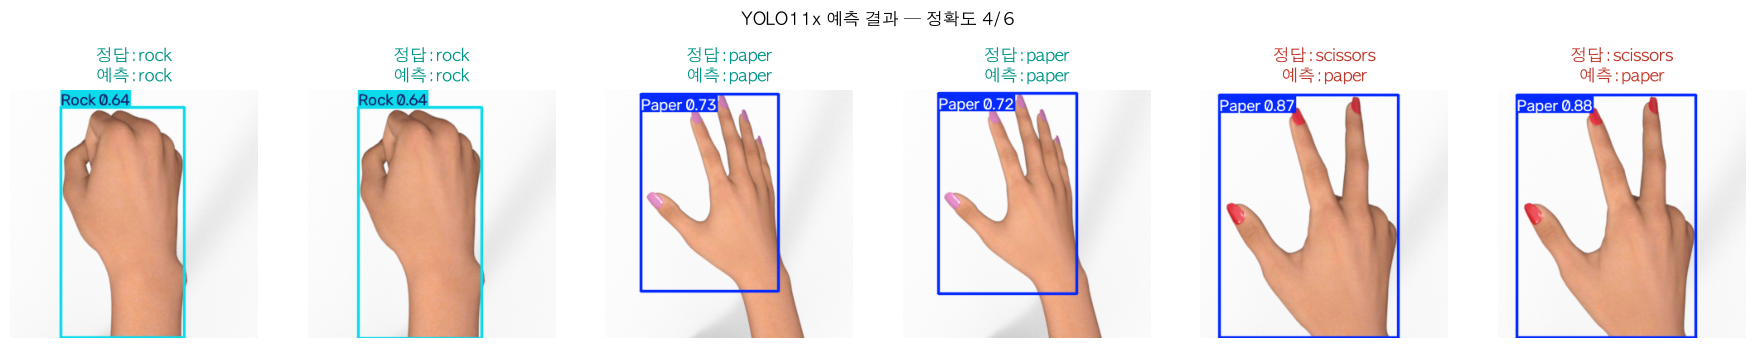

In [6]:
from matplotlib import font_manager

# 그래프 안의 한글이 깨지지 않도록(□□□) OS별로 있는 한글 폰트를 하나 고른다.
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _font in ("AppleGothic", "Malgun Gothic", "NanumGothic"):
    if _font in _installed:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
for ax, name in zip(axes, FIXTURES):
    box_result = model.predict(images[name], device=device, imgsz=640, conf=0.25, verbose=False)[0]
    annotated = box_result.plot()  # 박스·클래스명·신뢰도가 이미 그려진 BGR 이미지
    predicted = detect_move(images[name], device=device)
    pred_label = predicted[0] if predicted else "UNKNOWN"
    ok = pred_label == TRUTH[name]
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(f"정답:{TRUTH[name]}\n예측:{pred_label}", color="#009688" if ok else "#c0392b")
    ax.axis("off")
plt.suptitle(f"YOLO11x 예측 결과 — 정확도 {correct}/{len(FIXTURES)}")
plt.tight_layout(rect=(0, 0, 1, 0.92))  # suptitle이 각 패널 제목을 덮지 않도록 상단 여백 확보
plt.show()

## 5. 확신도가 높다고 정답은 아니다

가위 2장이 **0.87~0.88의 높은 확신도로 "paper"로 오분류**되는 것을 확인했을
것입니다. 이 프로젝트의 README는 원인을 이렇게 설명합니다: "정지 이미지 픽스처(CG
렌더)는 학습 분포(실사 웹캠)와 달라 가위를 보로 오분류하지만, 같은 손모양을 실사
영상에서는 0.92~0.94 신뢰도로 정확히 잡는다." 즉 이 4/6은 **모델 결함이 아니라
합성 이미지가 학습 분포 밖에 있다는 신호**입니다 — 확신도만 보고 모델을 신뢰하면
안 되는 이유입니다.

---

## AI Pair 섹션

### 1️⃣ Solo — 직접 해보기
`conf` 임계값을 0.5, 0.7로 올려가며 6장 정확도가 어떻게 바뀌는지 확인해보세요.
임계값을 올리면 오검출은 줄지만, 확신도가 낮은 정답까지 함께 걸러질 수 있습니다.

### 2️⃣ Review — AI에게 리뷰 받기
아래 프롬프트를 ChatGPT/Claude에 그대로 복사해서 물어보세요:

> "YOLO 모델이 학습 시 못 본 분포의 이미지(예: CG 렌더링 이미지를 실사 웹캠으로
> 학습한 모델에 넣는 경우)에서 confidence가 오히려 더 높게 나올 수 있는 이유가 뭐야?"

### 3️⃣ Debug — 틀린 코드 고치기
아래 코드는 실행되지만 결과가 이상합니다. 어디가 문제인지 찾아 고쳐보세요.

In [7]:
# 이 코드는 에러 없이 실행되지만 항상 첫 번째로 검출된 박스만 반환합니다.
def detect_move_buggy(frame, *, device: str, conf: float = 0.25):
    result = model.predict(frame, device=device, imgsz=640, conf=conf, verbose=False)[0]
    if not len(result.boxes):
        return None
    best = result.boxes[0]  # 힌트: 여러 박스 중 "가장 신뢰도 높은" 것을 고르려면 어떻게 해야 할까요?
    class_name = model.names[int(best.cls)]
    return class_name, float(best.conf)

### 4️⃣ Prompt Card — 더 탐구해보기
- "같은 클래스 3종(가위/바위/보)인데 500 epoch 학습 모델과 3 epoch 토이 체크포인트의
  mAP50이 0.963 대 0.026으로 차이 나는 이유를 실험으로 어떻게 확인할 수 있을까?"
- "MoveStabilizer의 window·min_votes 값을 바꾸면 반응 속도와 안정성이 어떻게 trade-off될까?"
- "이 모델을 실시간 웹캠에 적용할 때 mps와 cpu의 FPS 차이를 직접 측정하려면 어떻게 할까?"

---

## 📚 세션 요약

**🎯 핵심 Takeaways**
- "모델이 로드된다"가 "쓸 수 있다"를 보장하지 않는다 — 체크포인트의 학습 상태(epoch 수, mAP)를 반드시 확인해야 한다.
- 확신도(confidence)가 높다고 정답이라는 보장은 없다 — 학습 분포 밖 입력에서는 특히 그렇다.
- 다수결 안정화(MoveStabilizer)는 단일 프레임의 노이즈를 줄이지만, 체계적인 분포 밖 오분류는 프레임을 더 모아도 해결되지 않는다.
- Apple Silicon에서는 mps 디바이스가 CPU 대비 약 4배 빠르다 — 실시간 앱에서는 디바이스 선택이 정확도만큼 중요하다.